
# Couette Flow Validation

This notebook validates the 2D start-up Couette-flow example against the transient analytical solution.

The case starts from rest, with the bottom wall fixed and the top wall moving at constant speed $U=0.1$. On the time window shown here, the solution is still transient, so the correct reference is the start-up Couette series solution rather than the steady linear profile.


## Compile And Run

CPU build used here:

```bash
cd /home/haotian/lattice_boltzmann_method/Examples/Couette_flow
make -j28 USE_MPI=FALSE USE_OMP=TRUE DEBUG=FALSE
```

CPU validation run used here:

```bash
OMP_NUM_THREADS=28 ./main2d.gnu.OMP.ex inputs   max_step=1000 stop_time=1000   amr.regrid_int=-1   amr.plot_file=out_validation/plt   amr.plot_int=25
```

The current shared-core code still shows a separate corruption under late dynamic regridding for this example, so the validation shown here uses a fixed initial AMR hierarchy with `amr.regrid_int=-1`.


## Analytical Solution

For start-up Couette flow in a channel $0 \le y \le H$ with

- $u_x(y,0)=0$
- $u_x(0,t)=0$
- $u_x(H,t)=U$

and kinematic viscosity $\nu$, the transient analytical solution is

$$
u_x(y,t) = U\frac{y}{H} + \frac{2U}{\pi} \sum_{n=1}^{\infty} \frac{(-1)^n}{n}
\sin\!\left(\frac{n\pi y}{H}\right)
\exp\!\left(-\frac{n^2\pi^2\nu t}{H^2}\right).$$

Here we use:

- $U = 0.1$
- $H = 64$
- $\nu = 0.064$


In [1]:

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yt

plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

PLOT_ROOT = Path('out_validation')
U_TOP = 0.1
H = 64.0
NU = 0.064
N_TERMS = 600


/home/haotian/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:

def exact_couette(y, t, u_top=U_TOP, height=H, nu=NU, terms=N_TERMS):
    y = np.asarray(y, dtype=float)
    base = u_top * y / height
    n = np.arange(1, terms + 1, dtype=float)[:, None]
    series = (
        (2.0 * u_top / np.pi)
        * ((-1.0) ** n / n)
        * np.sin(n * np.pi * y[None, :] / height)
        * np.exp(-(n * n) * (np.pi ** 2) * nu * t / (height * height))
    ).sum(axis=0)
    return base + series


def load_plotfile(plotfile):
    ds = yt.load(str(plotfile))
    ds.force_periodicity()
    level = ds.index.max_level
    ref = 2 ** level
    dims = np.array(ds.domain_dimensions, dtype=int) * ref
    cg = ds.smoothed_covering_grid(level=level, left_edge=ds.domain_left_edge, dims=dims)

    ux = np.array(cg[('boxlib', 'ux')])[:, :, 0]
    x = ds.domain_left_edge[0].d + (np.arange(dims[0]) + 0.5) * (ds.domain_width[0].d / dims[0])
    y = ds.domain_left_edge[1].d + (np.arange(dims[1]) + 0.5) * (ds.domain_width[1].d / dims[1])

    return {
        'plotfile': plotfile.name,
        'time': float(ds.current_time),
        'x': x,
        'y': y,
        'ux': ux,
    }


plotfiles = sorted(PLOT_ROOT.glob('plt*'))
results = [load_plotfile(p) for p in plotfiles]
len(results), results[0]['plotfile'], results[-1]['plotfile']


yt : [INFO     ] 2026-03-28 22:53:14,732 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-03-28 22:53:14,733 Parameters: domain_dimensions         = [64 64  1]


yt : [INFO     ] 2026-03-28 22:53:14,734 Parameters: domain_left_edge          = [0. 0. 0.]


yt : [INFO     ] 2026-03-28 22:53:14,734 Parameters: domain_right_edge         = [64. 64.  1.]


yt : [INFO     ] 2026-03-28 22:53:14,960 Parameters: current_time              = 25.0


...

yt : [INFO     ] 2026-03-28 22:53:20,628 Parameters: current_time              = 1000.0


yt : [INFO     ] 2026-03-28 22:53:20,629 Parameters: domain_dimensions         = [64 64  1]


yt : [INFO     ] 2026-03-28 22:53:20,629 Parameters: domain_left_edge          = [0. 0. 0.]


yt : [INFO     ] 2026-03-28 22:53:20,630 Parameters: domain_right_edge         = [64. 64.  1.]


(41, 'plt00000', 'plt01000')

In [3]:

records = []
for r in results:
    y = r['y']
    profile_num = r['ux'].mean(axis=0)
    profile_exact = exact_couette(y, r['time'])
    rel_l2 = np.sqrt(np.mean((profile_num - profile_exact) ** 2)) / max(np.sqrt(np.mean(profile_exact ** 2)), 1e-30)
    records.append({
        'plotfile': r['plotfile'],
        'time': r['time'],
        'ux_min': float(r['ux'].min()),
        'ux_max': float(r['ux'].max()),
        'profile_rel_l2': float(rel_l2),
    })
summary = pd.DataFrame(records)
summary.head(), summary.tail(3)


(   plotfile   time    ux_min    ux_max  profile_rel_l2
 0  plt00000    0.0  0.000000  0.000000        1.000000
 1  plt00025   25.0 -0.000931  0.087807        0.224539
 2  plt00050   50.0 -0.000861  0.091879        0.191397
 3  plt00075   75.0 -0.000800  0.093613        0.176595
 4  plt00100  100.0 -0.000784  0.094612        0.168277,
     plotfile    time    ux_min    ux_max  profile_rel_l2
 38  plt00950   950.0 -0.001819  0.098380        0.114355
 39  plt00975   975.0 -0.001836  0.098401        0.113758
 40  plt01000  1000.0 -0.001853  0.098421        0.113180)

In [4]:

summary[['plotfile', 'time', 'ux_max', 'profile_rel_l2']]


,plotfile,time,ux_max,profile_rel_l2
0,plt00000,0.0,0.000000,1.000000
1,plt00025,25.0,0.087807,0.224539
2,plt00050,50.0,0.091879,0.191397
3,plt00075,75.0,0.093613,0.176595
4,plt00100,100.0,0.094612,0.168277
5,plt00125,125.0,0.095257,0.162492
6,plt00150,150.0,0.095725,0.158044
7,plt00175,175.0,0.096085,0.154573
8,plt00200,200.0,0.096369,0.151685
9,plt00225,225.0,0.096600,0.149098


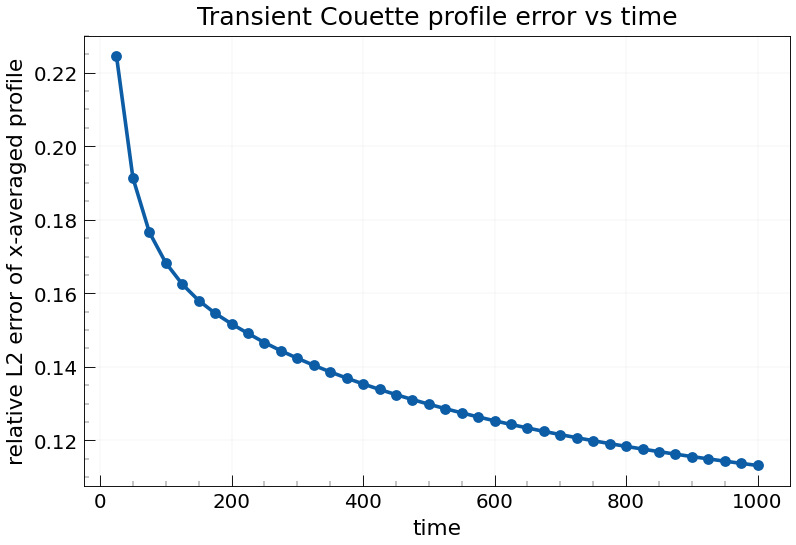

In [5]:

plot_summary = summary[summary['time'] > 0].copy()
fig, ax = plt.subplots()
ax.plot(plot_summary['time'], plot_summary['profile_rel_l2'], marker='o', linewidth=2)
ax.set_xlabel('time')
ax.set_ylabel('relative L2 error of x-averaged profile')
ax.set_title('Transient Couette profile error vs time')
plt.show()


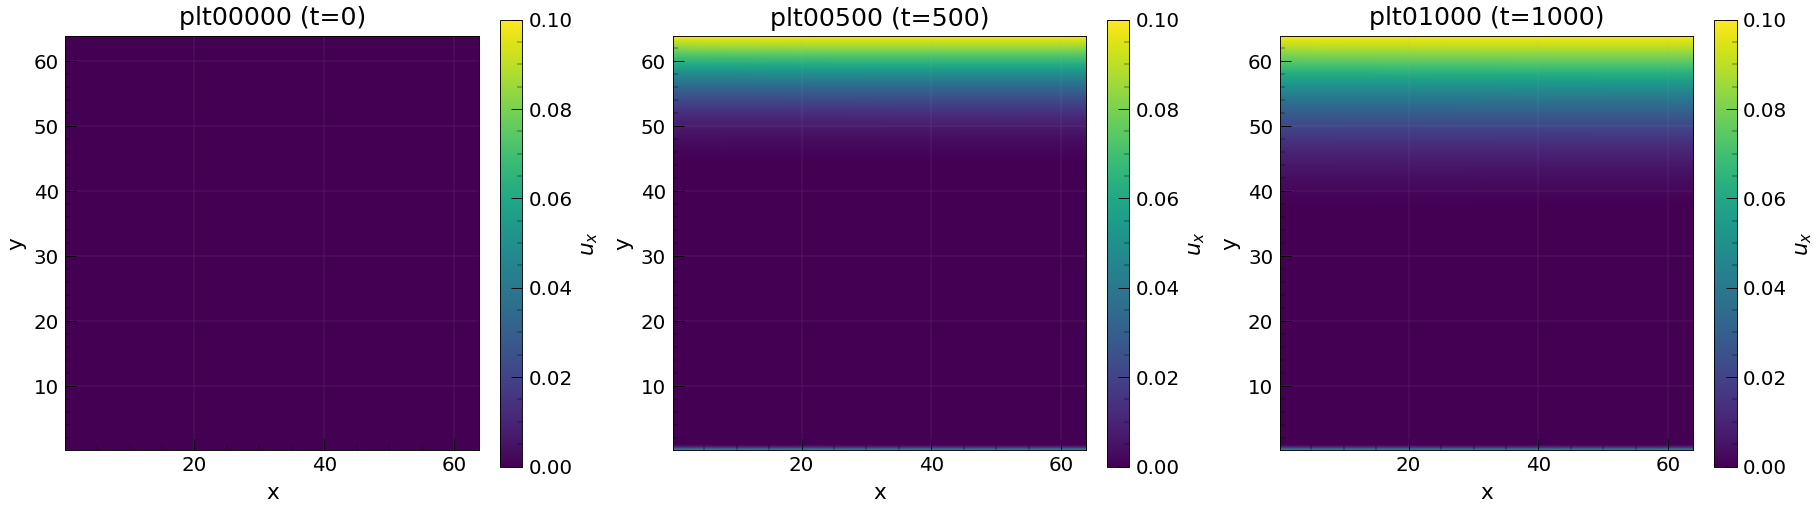

In [6]:

snapshots = [results[0], results[len(results)//2], results[-1]]
fig, axes = plt.subplots(1, len(snapshots), figsize=(14, 4.2), constrained_layout=True)
for ax, r in zip(axes, snapshots):
    im = ax.imshow(
        r['ux'].T,
        origin='lower',
        extent=[r['x'][0], r['x'][-1], r['y'][0], r['y'][-1]],
        cmap='viridis',
        vmin=0.0,
        vmax=U_TOP,
        aspect='equal',
    )
    ax.set_title(f"{r['plotfile']} (t={r['time']:.0f})")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax, shrink=0.85, label='$u_x$')
plt.show()


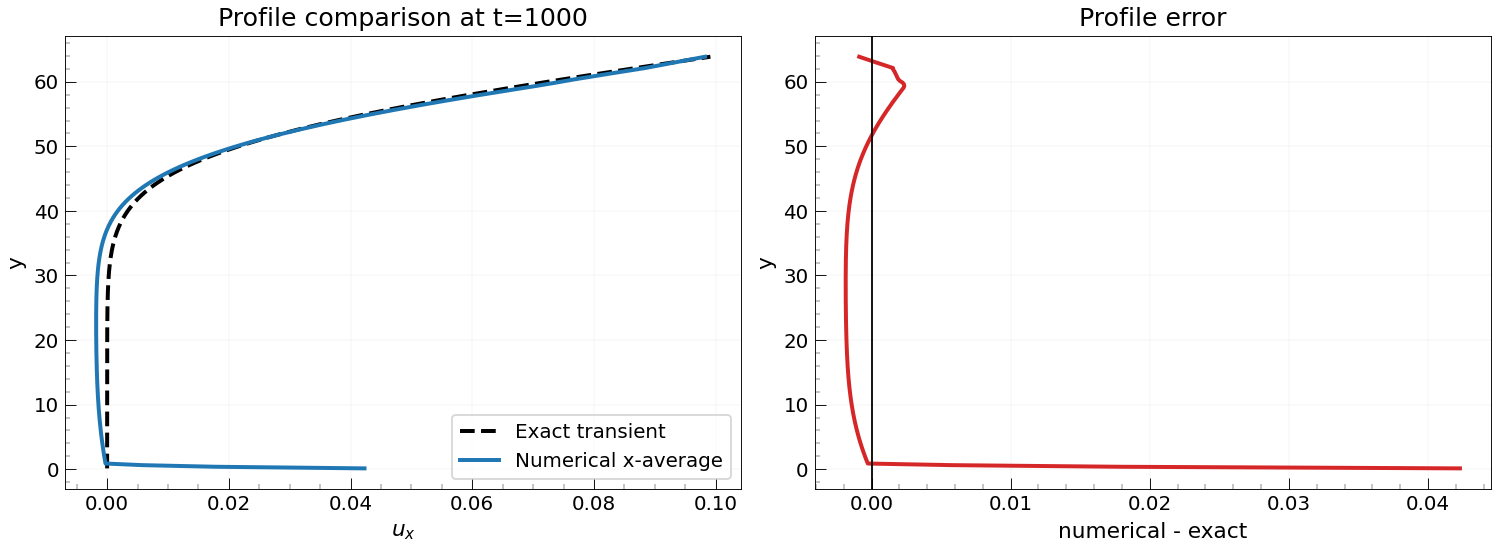

In [7]:

final = results[-1]
y = final['y']
profile_num = final['ux'].mean(axis=0)
profile_exact = exact_couette(y, final['time'])
profile_err = profile_num - profile_exact

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
axes[0].plot(profile_exact, y, 'k--', linewidth=2.2, label='Exact transient')
axes[0].plot(profile_num, y, color='#1f77b4', linewidth=2.2, label='Numerical x-average')
axes[0].set_xlabel('$u_x$')
axes[0].set_ylabel('y')
axes[0].set_title(f'Profile comparison at t={final["time"]:.0f}')
axes[0].legend(loc='lower right')

axes[1].plot(profile_err, y, color='#d62728', linewidth=2.2)
axes[1].axvline(0.0, color='k', linewidth=1)
axes[1].set_xlabel('numerical - exact')
axes[1].set_ylabel('y')
axes[1].set_title('Profile error')
plt.show()
